## `Input & Output streams`
### A stream is a **sequence of bytes**(流本质上是一串字节), representing a flow of data from a source to a destination
### java可以读取文件并且复写文件到终端
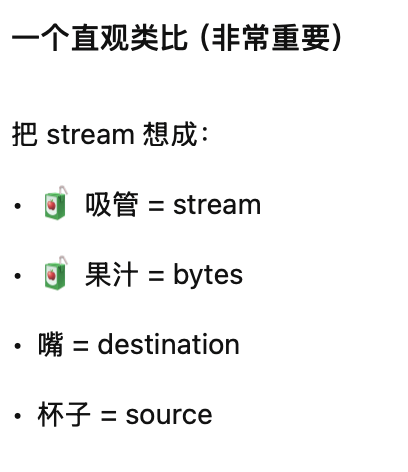
### writer 跟reader 为abstract class
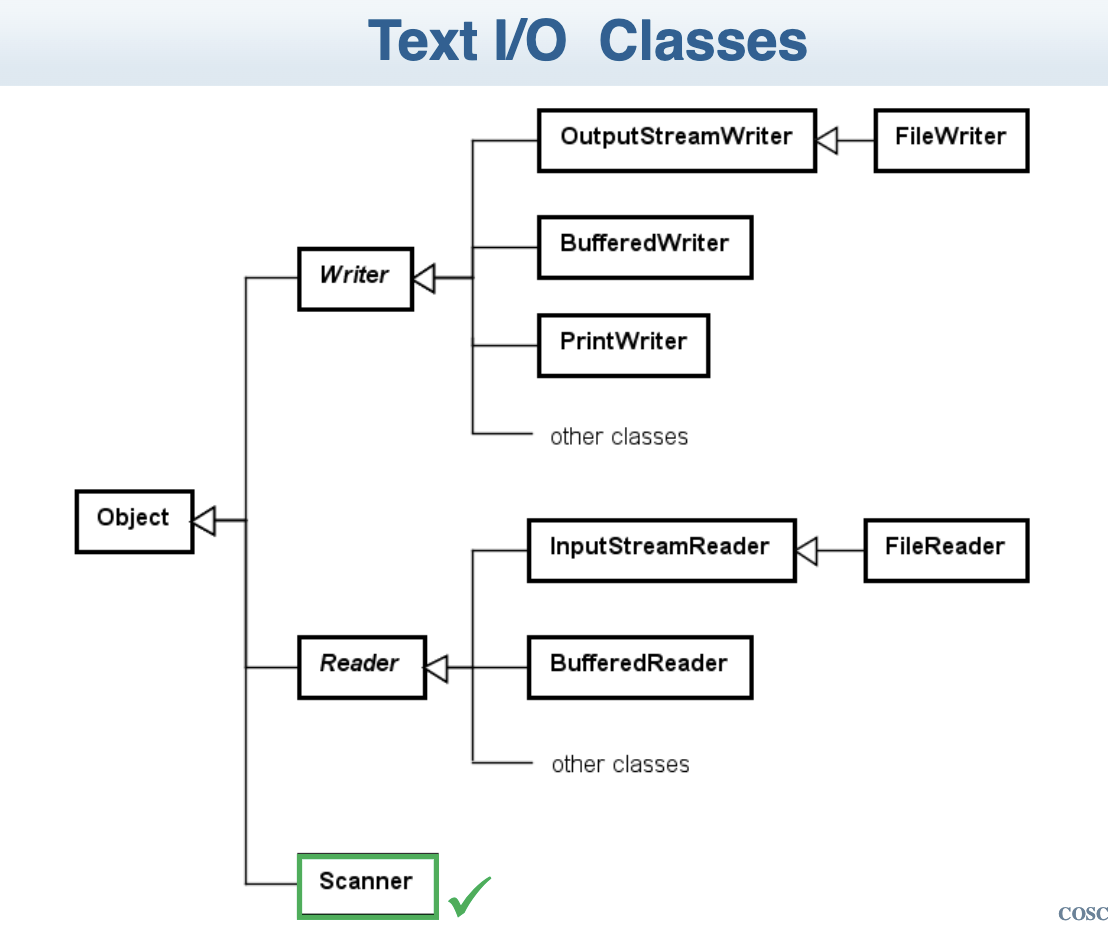

In [ ]:
import java.io.*;
import java.util.*;

public class L8 {
    public static void main(String[] args) throws IOException{
        //读取文件 对每个读取的内容进行分类+解析
        File f1 = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex2.txt");
        Scanner sc = new Scanner(new FileInputStream(f1));//读取+转换内容
        int f = sc.nextInt();
        System.out.println(f);
        sc.close();

        //写入文件，尤其append=true表示不清空原文件情况下接着写
        PrintWriter p1 = new PrintWriter(new BufferedWriter(new  FileWriter(f1,true)));
        p1.println("999");
        p1.close();

        //file reader 不对内容进行解析直接读取整行文本
        BufferedReader br = new BufferedReader(new InputStreamReader(new FileInputStream(f1)));
        String line;
        while ((line = br.readLine()) != null){
            System.out.println(line);
        }
        br.close();

        //file 里的try(){}
        File f2 = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex.txt");
        if(f2.exists()){
            System.out.println("exists");
            System.exit(0);
        }
        try(PrintWriter p2 = new PrintWriter(new BufferedWriter(new  FileWriter(f2,true)))) {
            p2.println("occupied now");
        }
    }
}

## `Scanner` , `Reader` , `Writer` , `File` class

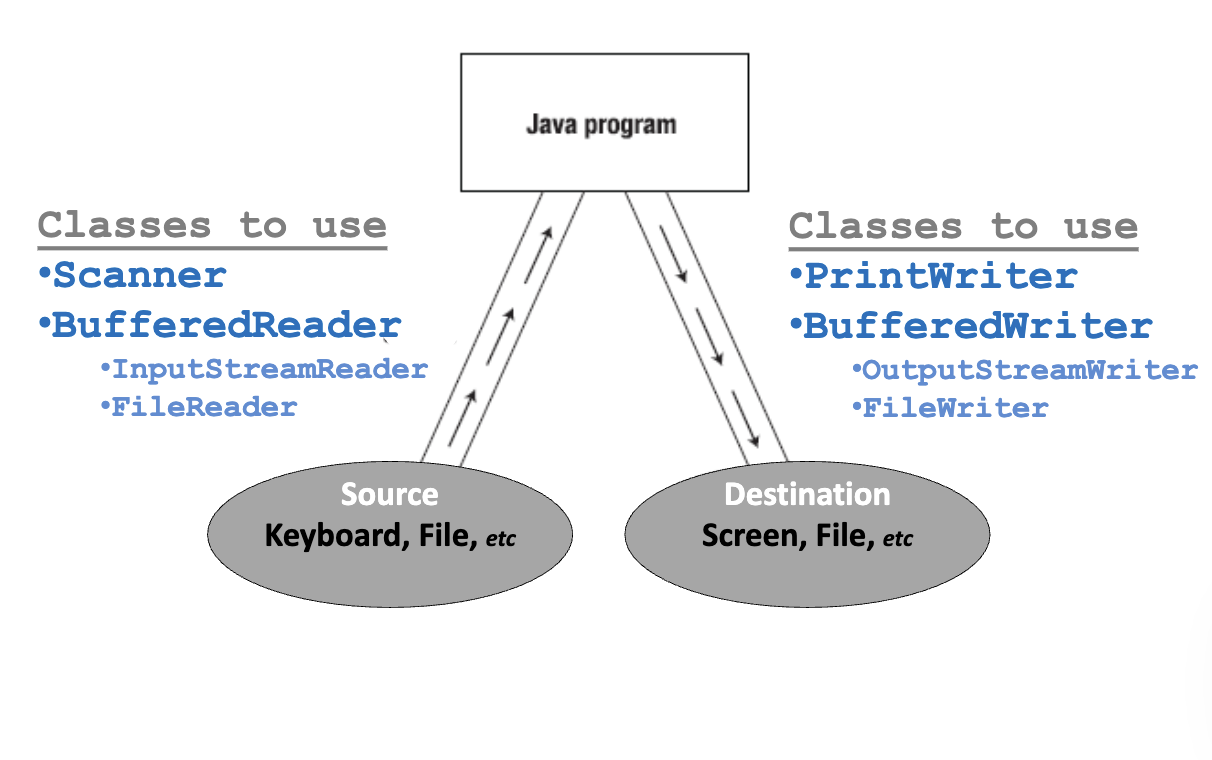

### **Library**

In [ ]:
import java.util.*; (include Scanner class)
imoprt java.io.*; (to use File class & use PrintWriter class & include IOException class)

In [ ]:
import java.io.*;
import java.util.*;

public class L8 {
    public static void main(String[] args) throws IOException{
        File f = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex.txt");
        Scanner sc = new Scanner(f);
        String s = sc.nextLine();
        System.out.println(s);
    }
}

### **Scanner** Syntax

In [ ]:
next()
nextLine()
nextInt()
nextDouble()
nextBoolean()
......
useDelimiter(String pattern)当文本并不是以空格为空白的时候需要修改读取的分隔条件，例如","

文本： 3,3,5,6

In [ ]:
import java.io.*;
import java.util.*;

public class L8 {
    public static void main(String[] args) throws IOException{
        File f = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex.txt");
        Scanner sc = new Scanner(f);
        sc.useDelimiter(",");//此时分隔条件为逗号
       while(sc.hasNextInt()){
           System.out.println(sc.nextInt());
       }
       sc.close();
    }
}
--------------------------------------------------------------------
3356

In [ ]:
布尔判断：
hasNext()
hasNextLine()
hasNextInt()
hasNextDouble()
hasNextBoolean()

#### `!在读取文本的时候出现的条件判断成功但是存在文本已经读完代码还没运行完所导致的exception`

In [ ]:
原：报错
import java.io.*;
import java.util.*;

public class L8 {
    public static void main(String[] args) throws IOException{
        File f = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex.txt");
        Scanner sc = new Scanner(f);
       while(sc.hasNext()){
           System.out.print(sc.next()+"\t");
           System.out.print(sc.nextInt()+"\t");
           System.out.print(sc.nextBoolean());
           System.out.println();
       }
       sc.close();
    }
}
apple	13	true
banana	14	true
orange	9	false
watermelon	87	false
beverage	100	Exception in thread "main" java.util.NoSuchElementException
	at java.base/java.util.Scanner.throwFor(Scanner.java:962)
	at java.base/java.util.Scanner.next(Scanner.java:1619)
	at java.base/java.util.Scanner.nextBoolean(Scanner.java:1919)
	at L8.main(L8.java:11)

In [ ]:
用try{}catch{}

        File f = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex.txt");
        Scanner sc = new Scanner(f);
        try{
            while(sc.hasNext()){
            System.out.print(sc.next()+"\t");
            System.out.print(sc.nextInt()+"\t");
            System.out.print(sc.nextBoolean());
            System.out.println();
        }
        }catch(NoSuchElementException e){
            System.out.println("\nMissing Element but done");
        }

       sc.close();
----------------------------------------------
apple	13	true
banana	14	true
orange	9	false
watermelon	87	false
beverage	100	
Missing Element but done

### **Reader** Syntax 
#### Reading from keyboard, file, url

In [ ]:
class InputStreamReader  字节流转字符流 更全面，更稳定
      read()
      read(char[] buf)
      close()
class FileReader 读字符文件(char) 只能读文件
      read()
      read(char[] buf)
      close()
class FileInputStream 读字节文件(byte) 只能读文件
      read()
      read(byte[] buf)
      read(byte[] buf, int off, int len)
      close()
class BufferedReader 读字符缓冲流  提高效率
      read()
      readLine()     // 一整行
      close()

In [ ]:
通用安全规范代码
BufferedReader br = new BufferReader(new InputStreamReader(new FileInputStream(f)));

In [ ]:
reading from URL
URL url = new URL("https://www.google.com");
Scanner input = new Scanner(url.openStream());

### **Writer** Syntax 

In [ ]:
 class PrintWriter 方便格式化输出
        print(...)
        println(...)
        printf(...)
        close()
 class BufferedWriter 提高效率
        write(String s)
        newLine()      // 跨平台换行
        flush()
        close()
 class FileWriter 写字符到文件
        write(String s)
        flush()
        close()

原：999
现：112233

In [ ]:
        Scanner origin = new Scanner(new FileReader("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex2.txt"));
        System.out.println(origin.nextInt());
        File file = new File("/Users/gwsmac/Desktop/cosc121/code/src/L8_ex2.txt");
        PrintWriter out = new PrintWriter(new BufferedWriter(new FileWriter(file)));
        out.println("112233");
        out.close();
        Scanner in = new Scanner(new FileReader(file));
        System.out.println(in.nextInt());


### **File** Syntax 

In [ ]:
exists() 文件是否存在
canRead() 文件是否可读
idDrectory() 是否为目录
isFile() 是否为文件

#### 使用try(){};避免忘记close
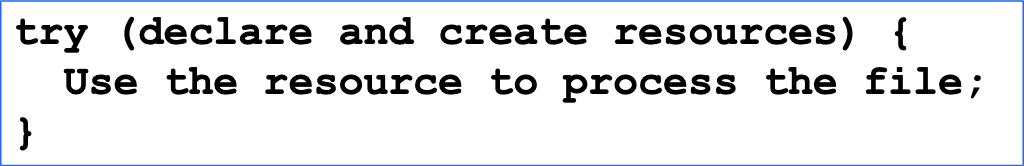